# 🌱 Green Fleet AI Decision System  

### AI-Powered CO₂ Emission Modeling for Government Fleet Procurement  

**Project Lead:** Abdelrahman Diaa (Diaa Shousha)  
**Role:** AI Engineer & Data Analyst  

---

## The Business Problem

A government agency must renew its vehicle fleet while staying under strict carbon emission limits.  
If the new vehicles exceed those limits, the agency could face legal penalties and environmental damage.

## My Goal

Build an AI system that can predict the CO₂ emissions of any vehicle *before* it is purchased.  
This allows decision-makers to choose vehicles that are environmentally compliant and policy-safe.

---

## 1️⃣ Technical Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

---
## 2️⃣ Data Ingestion & Validation

In [2]:
df = pd.read_csv("co2_emissions.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Dataset Shape: (4529, 13)

Missing Values:
 Model year        0
Make              0
Model             0
Vehicle class     0
Engine size       0
Cylinders         0
Transmission      0
Fuel type         0
City              0
Highway           0
Combined          0
Combined (mpg)    0
CO2 emissions     0
dtype: int64

Duplicate Rows: 0


,Model year,Make,Model,Vehicle class,Engine size,Cylinders,Transmission,Fuel type,City,Highway,Combined,Combined (mpg),CO2 emissions
0,2020,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,199
1,2020,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS9,Z,12.3,9.2,10.9,26,254
2,2020,Acura,MDX SH-AWD A-SPEC,Sport utility vehicle: Small,3.5,6,AS9,Z,12.2,9.5,11.0,26,258
3,2020,Acura,MDX Hybrid AWD,Sport utility vehicle: Small,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
4,2020,Acura,NSX,Two-seater,3.5,6,AM9,Z,11.1,10.8,11.0,26,261


### Data Validation Conclusion

The dataset contains 4,529 vehicle records across 13 structured features.  
No missing values or duplicate entries were detected.  

The dataset is clean and ready for exploratory analysis.

---
## 3️⃣ Target Variable Exploration  
### Distribution Analysis of CO₂ Emissions

C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


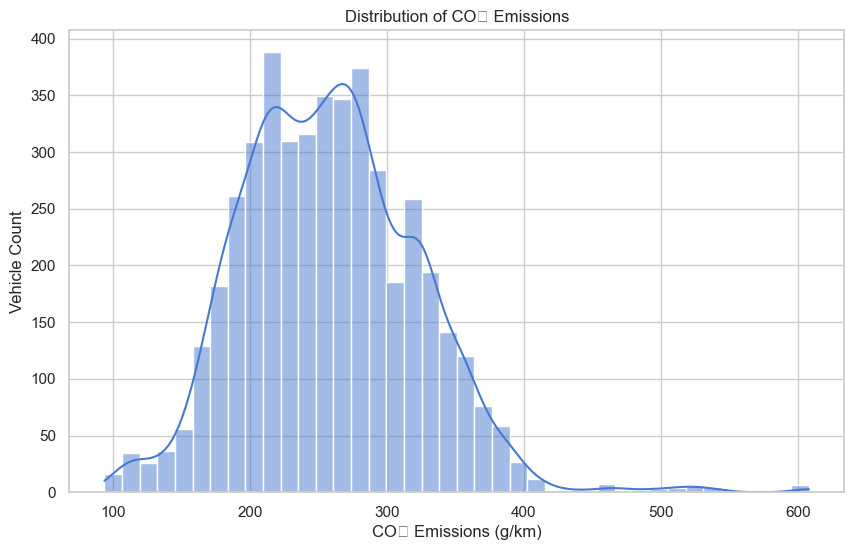

count    4529.000000
mean      258.396556
std        64.004089
min        94.000000
25%       213.000000
50%       256.000000
75%       299.000000
max       608.000000
Name: CO2 emissions, dtype: float64

Skewness: 0.5698433034235131
Kurtosis: 1.5450800657884374


In [3]:
# Distribution plot
plt.figure(figsize=(10,6))
sns.histplot(df["CO2 emissions"], bins=40, kde=True)

plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Vehicle Count")

plt.show()

# Statistical summary
summary = df["CO2 emissions"].describe()

print(summary)

print("\nSkewness:", df["CO2 emissions"].skew())
print("Kurtosis:", df["CO2 emissions"].kurt())

### Statistical Interpretation

- The average CO₂ emission across vehicles is approximately 258 g/km.
- The median (256 g/km) is close to the mean, suggesting a relatively symmetric distribution.
- Positive skewness (0.57) indicates a moderate right tail driven by high-emission vehicles.
- Kurtosis (>1) suggests the presence of some extreme emission values.

Overall, the target variable shows near-normal behavior with mild right skewness.  
This supports the use of regression-based modeling approaches while remaining aware of high-emission outliers.

---
## 4️⃣ Inferential Statistical Analysis  
### Compact vs Mid-size — Emission Comparison

In [4]:
df_compact = df[df["Vehicle class"] == "Compact"]
df_mid_size = df[df["Vehicle class"] == "Mid-size"]

tstat, pval = stats.ttest_ind(
    df_compact["CO2 emissions"],
    df_mid_size["CO2 emissions"],
    equal_var=False
)

print("P-value:", round(pval, 8))
print("T-statistic:", round(tstat, 4))

P-value: 4.014e-05
T-statistic: -4.127


In [5]:
print("Compact Mean:", df_compact["CO2 emissions"].mean())
print("Mid-size Mean:", df_mid_size["CO2 emissions"].mean())

Compact Mean: 212.54376657824935
Mid-size Mean: 227.88035714285715


### Statistical Interpretation

- The p-value is significantly below 0.05, indicating a statistically significant difference between Compact and Mid-size vehicles.
- The negative T-statistic confirms that Compact vehicles exhibit lower average CO₂ emissions.
- This result provides quantitative evidence to prioritize Compact vehicles in environmentally constrained procurement scenarios.

The statistical evidence supports narrowing fleet renewal strategies toward lower-emission vehicle classes.

---
## 5️⃣ Feature Relationship & Correlation Analysis  
### Identifying Key Drivers of CO₂ Emissions

,CO2 emissions
CO2 emissions,1.000000
Combined,0.969235
City,0.962699
Highway,0.931323
Engine size,0.813010
Combined (mpg),-0.914270


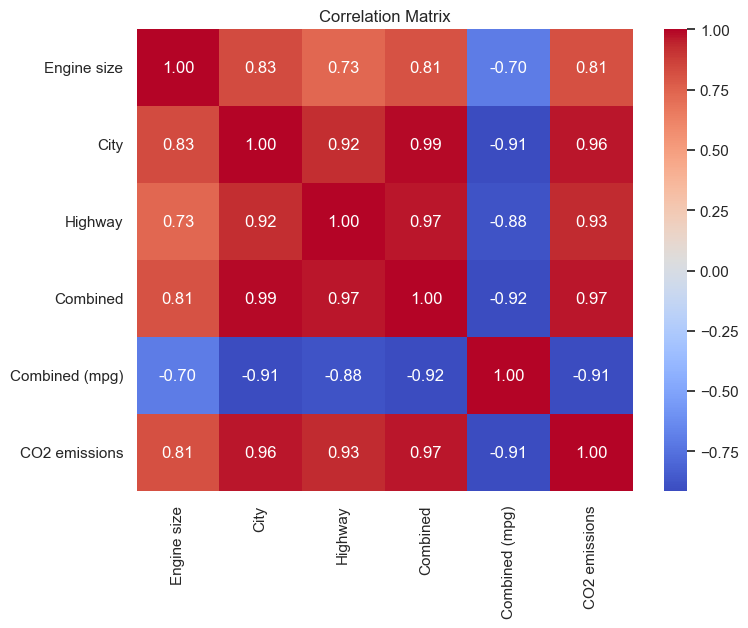

In [6]:
numeric_features = [
    'Engine size',
    'City',
    'Highway',
    'Combined',
    'Combined (mpg)',
    'CO2 emissions'
]

df_numeric = df[numeric_features]

# Correlation Matrix
correlation_matrix = df_numeric.corr()

display(
    correlation_matrix[['CO2 emissions']]
    .sort_values(by='CO2 emissions', ascending=False)
)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis Interpretation

- **Combined fuel consumption** exhibits the strongest positive correlation with CO₂ emissions (r ≈ 0.97), indicating it is the primary structural driver of emissions.
- **City consumption** also shows a very high correlation (r ≈ 0.96), reflecting the impact of urban driving conditions on carbon output.
- **Highway consumption** remains strongly correlated (r ≈ 0.93), though slightly less than city metrics.
- **Combined (mpg)** demonstrates a strong negative correlation (r ≈ -0.91), confirming that higher fuel efficiency corresponds to lower emissions.
- Significant inter-correlation between *City*, *Highway*, and *Combined* suggests multicollinearity, which must be addressed prior to regression modeling.

These findings guide feature selection and modeling strategy in subsequent stages.

---
## 6️⃣ Feature Selection Decision  
### Choosing the Optimal Predictor for CO₂ Emissions

In [7]:
correlation_matrix = df[numeric_features].corr()

correlation_matrix[['CO2 emissions']].sort_values(
    by='CO2 emissions', 
    ascending=False
)

,CO2 emissions
CO2 emissions,1.000000
Combined,0.969235
City,0.962699
Highway,0.931323
Engine size,0.813010
Combined (mpg),-0.914270


### Feature Selection Rationale

The correlation analysis reveals that **Combined fuel consumption** (r ≈ 0.97) and **City fuel consumption** (r ≈ 0.96) are the strongest predictors of CO₂ emissions.

However, due to operational context—where government fleet vehicles primarily operate in urban environments—the **City consumption metric** was selected as the primary regression variable.

Although "Combined" exhibits a slightly stronger correlation, selecting "City" aligns the modeling strategy with real-world fleet usage patterns.

This decision reflects both statistical evidence and engineering judgment.

----
## 7️⃣ Linear Regression Modeling  
### Predicting CO₂ Emissions Using City Fuel Consumption

In [8]:
X = sm.add_constant(df["City"])
y = df["CO2 emissions"]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2 emissions   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                 5.731e+04
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:49:35   Log-Likelihood:                -19341.
No. Observations:                4529   AIC:                         3.869e+04
Df Residuals:                    4527   BIC:                         3.870e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.2213      0.963     37.609      0.000      34.333      38.109
City          17.7845      0.074    239.390      0.000      17.639      17.930
==============================================================================
Omnibus:                     2908.624   Durbin-Watson:                   1.645
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            67852.518
Skew:                          -2.681   Prob(JB):                         0.00
Kurtosis:                      21.188   Cond. No.                         48.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model Interpretation

- **R-squared = 0.927**  
  The model explains approximately 92.7% of the variance in CO₂ emissions, indicating a very strong linear relationship.

- **City coefficient ≈ 17.78**  
  For every additional unit increase in city fuel consumption (L/100km), CO₂ emissions increase by approximately 17.8 g/km.

- **P-value < 0.001**  
  The City variable is statistically significant, confirming it is a reliable predictor of emissions.

### Conclusion

The regression model demonstrates that urban fuel consumption is a dominant driver of CO₂ emissions.  
The strong R² and statistical significance validate the earlier feature selection decision.

---
## 8️⃣ Multivariate Regression Modeling  
### Incorporating Categorical Effects (Fuel Type Impact)

In [9]:
# Creating dummy variables for Fuel Type
fuel_dummies = pd.get_dummies(df["Fuel type"], drop_first=True, dtype=float)

# Combining predictors
X_multi = pd.concat([df["City"], fuel_dummies], axis=1)
X_multi = sm.add_constant(X_multi)

y = df["CO2 emissions"]

# Ensure all predictors are numeric
X_multi = X_multi.astype(float)

# Build model
model_multi = sm.OLS(y, X_multi)
results_multi = model_multi.fit()

results_multi.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2 emissions   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 5.217e+04
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:49:35   Log-Likelihood:                -16537.
No. Observations:                4529   AIC:                         3.308e+04
Df Residuals:                    4524   BIC:                         3.312e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         55.3992      1.003     55.233      0.000      53.433      57.366
City          19.2503      0.045    432.274      0.000      19.163      19.338
E           -147.9444      1.451   -101.967      0.000    -150.789    -145.100
X            -34.0815      0.894    -38.139      0.000     -35.833     -32.330
Z            -38.9503      0.898    -43.399      0.000     -40.710     -37.191
==============================================================================
Omnibus:                      635.851   Durbin-Watson:                   0.888
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2466.541
Skew:                           0.658   Prob(JB):                         0.00
Kurtosis:                       6.367   Cond. No.                         175.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Multivariate Regression Interpretation

The extended model incorporating **Fuel Type** significantly improves predictive performance.

- **R² = 0.979**
  The model now explains 97.9% of the variance in CO₂ emissions — a substantial improvement over the simple regression model.

- **City Coefficient ≈ 19.25**
  Each additional unit of city fuel consumption increases CO₂ emissions by approximately 19.3 g/km, holding fuel type constant.

- **Fuel Type Effects**
  The negative coefficients for alternative fuel categories (e.g., E, X, Z) indicate structural reductions in emissions relative to the baseline fuel category.

- **All predictors are statistically significant (p < 0.001)**  
  This confirms that both operational usage (City) and fuel composition materially influence emissions.

---

### Strategic Interpretation

The inclusion of fuel type reveals that emissions are not solely driven by consumption intensity but also by underlying combustion technology.

This multivariate model provides a more realistic and policy-aligned decision framework for fleet procurement.

---

## 9️⃣ Model Comparison & Final Selection

In [10]:
print(f"Simple Model R²: {results.rsquared:.4f}")
print(f"Multivariate Model R²: {results_multi.rsquared:.4f}")

improvement = results_multi.rsquared - results.rsquared
print(f"Improvement in R²: {improvement:.4f}")

Simple Model R²: 0.9268
Multivariate Model R²: 0.9788
Improvement in R²: 0.0520


### Model Performance Comparison

The multivariate regression model substantially improves predictive performance:

- Simple Model R²: 0.9268  
- Multivariate Model R²: 0.9788  
- Improvement: +0.0520  

The addition of fuel type variables captures structural emission differences that were not explained by city consumption alone.

---

### Final Model Selection

Given its superior explanatory power and structural realism,  
the multivariate regression model is selected as the final predictive framework.

---
## 🔟 Model Operationalization  
### Converting the Final Regression Model into a Prediction Tool

In [14]:
def predict_emissions(city_consumption, fuel_type):
    
    # Initialize input structure بنفس أعمدة X_multi
    input_data = {col: 0 for col in X_multi.columns}
    
    # Set City value
    input_data["City"] = city_consumption
    
    # Set fuel dummy
    if fuel_type in input_data:
        input_data[fuel_type] = 1
    
    # Create DataFrame بنفس ترتيب التدريب
    input_df = pd.DataFrame([input_data])
    
    prediction = results_multi.predict(input_df)
    
    return float(prediction.iloc[0])

In [15]:
pred = predict_emissions(9.5, "Fuel type_Z")
print(f"Predicted CO₂ Emissions: {pred:.2f} g/km")

Predicted CO₂ Emissions: 182.88 g/km


---

## 1️⃣1️⃣ Final Model Validation & Policy Recommendation

In this final stage, the selected multivariate regression model is applied to previously unseen vehicle data to simulate real-world deployment.  
The objective is to evaluate the model’s generalization capability and support an evidence-based procurement decision for the agency.

---

In [ ]:
test_df = pd.read_csv("test_cars.csv")

predictors = ["City", "Fuel type"]

fuel_type_dummies_test = pd.get_dummies(
    test_df[predictors],
    columns=["Fuel type"],
    dtype=int
)


fuel_type_dummies_test = fuel_type_dummies_test.reindex(
    columns=X_multi.columns.drop('const'),
    fill_value=0
)


X_test_multi = sm.add_constant(fuel_type_dummies_test)

predictions_test_multi = results_multi.predict(X_test_multi)

In [21]:
print("Predictions using the selected model:\n")

for i in range(len(predictions_test_multi)):
    print(
        f"{test_df['Model year'][i]} "
        f"{test_df['Make'][i]} "
        f"{test_df['Model'][i]} → "
        f"{predictions_test_multi[i]:.2f} g/km"
    )

Predictions using the selected model:

2023 Kia Forte → 213.25 g/km
2024 Nissan Sentra → 197.85 g/km
2023 Honda Accord → 161.85 g/km
2024 Genesis G70 → 280.63 g/km


---

## 🏆 Strategic Procurement Recommendation

Based on the multivariate regression model predictions, the shortlisted vehicles are ranked as follows:

| Vehicle Model | Predicted CO₂ (g/km) | Assessment |
| :--- | :--- | :--- |
| **2023 Honda Accord** | **161.85** | ✅ Recommended |
| 2024 Nissan Sentra | 197.85 | Moderate Emissions |
| 2023 Kia Forte | 213.25 | High Emissions |
| 2024 Genesis G70 | 280.63 | Very High Emissions |

### Final Decision

The **2023 Honda Accord** is recommended for procurement, as it demonstrates the lowest projected CO₂ emissions among the shortlisted vehicles.

Selecting this model aligns with environmental compliance objectives and supports long-term sustainability goals.

*Data-driven decisions enable responsible and measurable environmental impact management.*

---